# **EDHEC MSc FINANCIAL ENGINEERING - INTRODUCTION TO MACHINE LEARNING**

### JADE BLANC (85750) - MARIE CALDEIREIRO (85769) - ANAS LAMRI (85878)

### **Task A — Credit Default Prediction (Classification)**

In [1]:
import numpy as np

class GaussianNaiveBayes:
    def __init__(self):
        self.classes_ = None        # valeurs possibles de Y (par ex. [0, 1])
        self.class_prior_ = None    # P(Y = y)
        self.theta_ = None          # moyennes conditionnelles mu_{j|y}
        self.var_ = None            # variances conditionnelles sigma2_{j|y}

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape

        # Classes possibles et indices correspondants
        self.classes_, y_indices = np.unique(y, return_inverse=True)
        n_classes = len(self.classes_)

        # Initialisation des paramètres
        self.class_prior_ = np.zeros(n_classes)
        self.theta_ = np.zeros((n_classes, n_features))
        self.var_ = np.zeros((n_classes, n_features))

        # Boucle sur les classes (0 et 1)
        for idx, c in enumerate(self.classes_):
            # Sous-échantillon des clients de la classe c
            X_c = X[y == c]

            # 1) Probabilité a priori P(Y = c) = fréquence de la classe
            self.class_prior_[idx] = X_c.shape[0] / n_samples

            # 2) Moyenne et variance de chaque feature dans cette classe
            self.theta_[idx, :] = X_c.mean(axis=0)
            self.var_[idx, :] = X_c.var(axis=0) + 1e-6  # +epsilon pour éviter /0

        return self

    def _joint_log_likelihood(self, X):
        X = np.asarray(X)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        log_likelihood = np.zeros((n_samples, n_classes))

        for idx in range(n_classes):
            # log P(Y = c)
            log_prior = np.log(self.class_prior_[idx])

            # Paramètres gaussiens pour la classe c
            mean = self.theta_[idx]
            var = self.var_[idx]

            # log densité gaussienne pour chaque feature (indépendance -> somme)
            # log N(x | mu, sigma^2) = -0.5 * [ log(2πσ^2) + (x - mu)^2 / σ^2 ]
            log_prob = -0.5 * (
                np.log(2.0 * np.pi * var) + ((X - mean) ** 2) / var
            )

            # somme sur les features + log P(Y = c)
            log_likelihood[:, idx] = log_prior + log_prob.sum(axis=1)

        return log_likelihood

    def predict_proba(self, X):
        log_likelihood = self._joint_log_likelihood(X)

        # Pour la stabilité numérique : on soustrait le max avant exponentielle
        max_log = np.max(log_likelihood, axis=1, keepdims=True)
        shifted = log_likelihood - max_log
        exp_shifted = np.exp(shifted)
        probs = exp_shifted / exp_shifted.sum(axis=1, keepdims=True)

        return probs  # colonne 0: P(Y=classe_0), colonne 1: P(Y=classe_1)

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)

        # position de la classe "1" dans self.classes_
        idx_class1 = list(self.classes_).index(1)
        p_default = probs[:, idx_class1]

        # 1 si probabilité de défaut >= threshold, sinon 0
        y_pred = (p_default >= threshold).astype(int)
        return y_pred


In [2]:
import numpy as np
import pandas as pd

# Fix random seed
rng = np.random.default_rng(42)

# Generate synthetic features
n_samples = 5000

# Age: normal around 40, clipped between 21 and 75
age = rng.normal(loc=40, scale=10, size=n_samples)
age = np.clip(age, 21, 75)

# Annual income (in thousands USD): lognormal-like (typical of income distributions)
income_k = rng.lognormal(mean=3.7, sigma=0.5, size=n_samples)
income_k = np.clip(income_k, 10, 250)  # avoid unrealistic extremes

# Debt ratio between 0 and 1
debt_ratio = rng.beta(a=2.0, b=5.0, size=n_samples)

# Past defaults: Poisson distribution
past_defaults = rng.poisson(lam=0.3, size=n_samples)
past_defaults = np.clip(past_defaults, 0, 5)

# Credit score between 300 and 850
credit_score = rng.normal(loc=650, scale=80, size=n_samples)
credit_score = np.clip(credit_score, 300, 850)

# True probability of default (logistic model)
logit = (
    -6.0
    + 0.03 * (50 - income_k)        # lower income → higher risk
    + 4.0 * (debt_ratio - 0.3)      # high debt ratio → higher risk
    + 0.8 * past_defaults           # more past defaults → higher risk
    + 0.004 * (620 - credit_score)  # low credit score → higher risk
)

true_p_default = 1 / (1 + np.exp(-logit))

# Sample actual default from Bernoulli(true_p_default)
default = rng.binomial(1, true_p_default, size=n_samples)

# Build DataFrame
data = pd.DataFrame({
    "age": age,
    "income_k": income_k,
    "debt_ratio": debt_ratio,
    "past_defaults": past_defaults,
    "credit_score": credit_score,
    "default": default,
    "true_p_default": true_p_default
})

# Display first rows
print(data.head())


         age   income_k  debt_ratio  past_defaults  credit_score  default  \
0  43.047171  35.552979    0.404951              0    687.144072        0   
1  29.600159  34.822268    0.055957              0    503.520065        0   
2  47.504512  28.550374    0.698594              0    578.405187        0   
3  49.405647  50.111046    0.353384              0    709.208093        0   
4  21.000000  45.482293    0.138969              0    850.000000        0   

   true_p_default  
0        0.004428  
1        0.002341  
2        0.026707  
3        0.002136  
4        0.000594  


In [3]:

# Features and target
feature_cols = ["age", "income_k", "debt_ratio", "past_defaults", "credit_score"]
X = data[feature_cols].values
y = data["default"].values

# Instantiate and train the model
nb_model = GaussianNaiveBayes()
nb_model.fit(X, y)

# Display model parameters (A.1 expected output)

print("\nClasses :", nb_model.classes_)  # [0 1]
print("Priors (P(Y=c)) :", nb_model.class_prior_)   # frequencies of default/no default

print("\nMeans of each feature by class (theta_):")
for i, c in enumerate(nb_model.classes_):
    print(f"Class {c} :", nb_model.theta_[i])

print("\nVariances of each feature by class (var_):")
for i, c in enumerate(nb_model.classes_):
    print(f"Class {c} :", nb_model.var_[i])

# Example: predicted default probability for a new client

new_client = np.array([[35, 40, 0.5, 1, 620]])  # [age, income_k, debt_ratio, past_defaults, credit_score]

probs = nb_model.predict_proba(new_client)

print("\nProbabilité que ce client ne fasse PAS défaut : ", probs[0, 0])
print("Probabilité que ce client fasse défaut :        ", probs[0, 1])



Classes : [0 1]
Priors (P(Y=c)) : [0.9946 0.0054]

Means of each feature by class (theta_):
Class 0 : [3.99111472e+01 4.60087850e+01 2.82966293e-01 2.84938669e-01
 6.48089514e+02]
Class 1 : [4.14500012e+01 3.72957228e+01 3.43660321e-01 4.44444444e-01
 6.31794977e+02]

Variances of each feature by class (var_):
Class 0 : [9.47586133e+01 6.15213136e+02 2.55649270e-02 2.82575282e-01
 6.47656018e+03]
Class 1 : [6.76798908e+01 5.23879373e+02 2.43556466e-02 4.69136802e-01
 8.02626106e+03]

Probabilité que ce client ne fasse PAS défaut :  0.9880384616331097
Probabilité que ce client fasse défaut :         0.011961538366890432


### **Task B — Asset Return Modeling Using Kernel Meth- ods (Regression)**

In [4]:
#Preliminary imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### B.1 Data Simulation and Problem Setup

In [5]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of observations
n = 260 # Approx. number of trading days in a year

# Simulate two market factors
# Factor 1: Past returns (normally distributed)
past_returns = np.random.normal(0.05, 0.15, n) # Mean return of 5%, std dev of 15%

# Factor 2: Volatility indicator (chi-squared distribution to ensure positive values)
volatility = np.random.chisquare(df=3, size=n) / 10 # Scale down for realistic volatility values

# Introduce regime-switching effect based on volatility
# Define high and low volatility regimes
high_vol_regime = volatility > np.median(volatility)
low_vol_regime = ~high_vol_regime # NOT high volatility

# Simulate asset returns with nonlinear regime-switching pattern
asset_return = np.zeros(n)

# Low volatility regime: linear relationship with moderate sensitivity
asset_return[low_vol_regime] = (
    0.8 * past_returns[low_vol_regime] 
    - 0.3 * volatility[low_vol_regime] 
    + np.random.normal(0, 0.02, np.sum(low_vol_regime))
)

# High volatility regime: nonlinear relationship with amplified effects
asset_return[high_vol_regime] = (
    1.5 * past_returns[high_vol_regime] 
    - 0.8 * volatility[high_vol_regime]**2  # Quadratic effect
    + 0.5 * past_returns[high_vol_regime] * volatility[high_vol_regime]  # Interaction term
    + np.random.normal(0, 0.05, np.sum(high_vol_regime))
)

# Create DataFrame
df_asset = pd.DataFrame({
    'Past_Returns': past_returns,
    'Volatility': volatility,
    'Asset_Return': asset_return,
    'Regime': ['High Vol' if hv else 'Low Vol' for hv in high_vol_regime]
})

# Display summary statistics
print("Dataset Summary:")
print(df_asset.head())
print()
print(df_asset.describe())
print(f"\nRegime Distribution:")
print(df_asset['Regime'].value_counts())


Dataset Summary:
   Past_Returns  Volatility  Asset_Return   Regime
0      0.124507    0.084912      0.078049  Low Vol
1      0.029260    0.220709     -0.062372  Low Vol
2      0.147153    0.182915      0.071013  Low Vol
3      0.278454    0.054256      0.172435  Low Vol
4      0.014877    0.150598     -0.012695  Low Vol

       Past_Returns  Volatility  Asset_Return
count    260.000000  260.000000    260.000000
mean       0.051142    0.292120     -0.057064
std        0.146132    0.245665      0.264630
min       -0.342962    0.007477     -1.573908
25%       -0.052830    0.125002     -0.153349
50%        0.059338    0.224064     -0.033834
75%        0.144160    0.387319      0.093213
max        0.627910    1.347589      0.631242

Regime Distribution:
Regime
Low Vol     130
High Vol    130
Name: count, dtype: int64


#### B.2 Linear vs. Nonlinear Modeling

In [6]:
# Preliminary imports
import statsmodels.api as sm

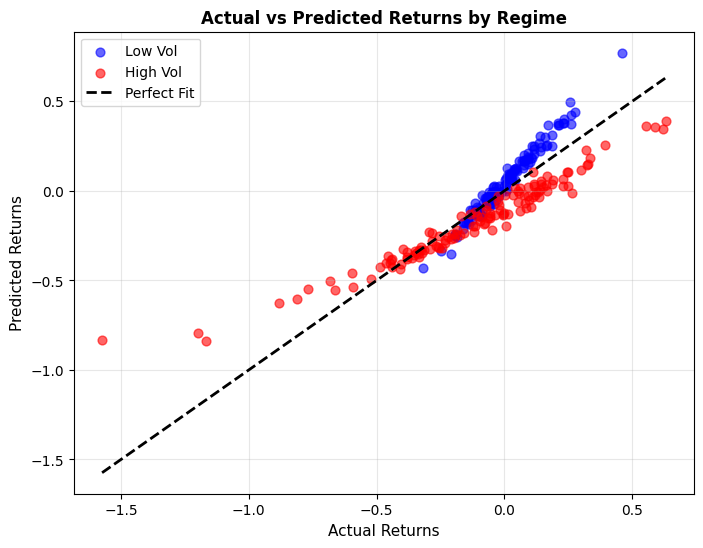

Linear Regression Model (Statsmodels)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     562.1
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           1.41e-94
Time:                        12:19:52   Log-Likelihood:                 195.85
No. Observations:                 260   AIC:                            -385.7
Df Residuals:                     257   BIC:                            -375.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

<Figure size 640x480 with 0 Axes>

In [7]:
# Prepare features and target
X = df_asset[['Past_Returns', 'Volatility']].values
y = df_asset['Asset_Return'].values

# Add constant for statsmodels
X_with_const = sm.add_constant(X)

# Fit linear regression model with statsmodels
linear_model = sm.OLS(y, X_with_const).fit()

# Visualizations for Linear Model
# Get predictions and residuals
y_pred_linear = linear_model.predict(X_with_const)
residuals = linear_model.resid
# Actual vs Predicted by Regime
plt.figure(figsize=(8, 6))
colors = {'High Vol': 'red', 'Low Vol': 'blue'}
for regime in df_asset['Regime'].unique():
    mask = df_asset['Regime'] == regime
    plt.scatter(y[mask], y_pred_linear[mask], alpha=0.6, 
                label=regime, color=colors[regime], s=40)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Returns', fontsize=11)
plt.ylabel('Predicted Returns', fontsize=11)
plt.title('Actual vs Predicted Returns by Regime', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig('actual_vs_predicted_by_regime.png', dpi=300, bbox_inches='tight')

# Display results
print("Linear Regression Model (Statsmodels)")
print("=" * 50)
print(linear_model.summary())
print("\n" + "=" * 50)
print(f"\nPerformance Metrics:")
print(f"  MSE:  {linear_model.mse_resid:.6f}")
print(f"  R²:   {linear_model.rsquared:.4f}")
print(f"  Adjusted R²: {linear_model.rsquared_adj:.4f}")

##### Interpretation

1. How well does the linear model fit the data?

The linear regression provides a strong overall fit. The model achieves an R² of 0.814 (adjusted R² = 0.812), meaning it explains around 81% of the variation in asset returns.
Both predictors are highly significant: past returns have a strong positive effect (coef = 1.19, t = 24.48, p < 0.001) and volatility has a strong negative effect (coef = –0.65, t = –22.43, p < 0.001). 

The low MSE (0.0131) also indicates good predictive accuracy.
Overall, the linear model performs well as a baseline.  

The scatter plot of Actual vs Predicted Returns broadly supports this: most points lie close to the perfect-fit line, especially in the low-volatility regime (blue points), where prediction errors are smaller and more symmetric.

2. Does the linear model fail to capture the nonlinear pattern introduced?

Yes. Despite the high R², the residual diagnostics clearly indicate nonlinearity.
The residual distribution fails normality tests: the Omnibus test (p < 0.001) and the extremely large Jarque–Bera statistic (JB = 532.1) show strong skewness (–1.18) and heavy tails (kurtosis = 9.60).  

These patterns suggest systematic structure left in the residuals, meaning the linear model cannot fully capture the nonlinear relationship intentionally built into the data.  

The graph reinforces this: in the high-volatility regime (red points), predictions consistently fall above or below the perfect-fit line in a curved pattern, showing that the true relationship bends while the linear model forces a straight line. This systematic deviation across volatility levels visually confirms that the model does not capture the nonlinear structure.

In [8]:
# Define polynomial kernel function (degree 2)
def polynomial_kernel(x1, x2, degree=2, c=1):
    """
    Compute polynomial kernel between two data points or matrices.
    K(x1, x2) = (x1 · x2 + c)^degree
    
    Parameters:
    - x1, x2: input vectors or matrices
    - degree: degree of polynomial (default=2)
    - c: constant term (default=1)
    """
    return (np.dot(x1, x2.T) + c) ** degree

# Compute the Gram (kernel) matrix for training data
def compute_gram_matrix(X, kernel_func, **kernel_params):
    """
    Compute the Gram matrix K where K[i,j] = kernel(X[i], X[j])
    
    Parameters:
    - X: training data matrix (n_samples x n_features)
    - kernel_func: kernel function to use
    - kernel_params: parameters for the kernel function
    """
    n = X.shape[0]
    K = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            K[i, j] = kernel_func(X[i:i+1], X[j:j+1], **kernel_params)
    
    return K


#### B.3 Gram Matrix Construction

In [9]:
# Kernel Regression Model using Gram Matrix

# Compute Gram matrix using polynomial kernel (degree 2)
K_train = compute_gram_matrix(X, polynomial_kernel, degree=2, c=1)

print("Gram Matrix Construction")
print("=" * 50)
print(f"Gram matrix shape: {K_train.shape}")
print(f"Gram matrix symmetry check: {np.allclose(K_train, K_train.T)}")
print(f"\nGram matrix statistics:")
print(f"  Min value:  {K_train.min():.4f}")
print(f"  Max value:  {K_train.max():.4f}")
print(f"  Mean value: {K_train.mean():.4f}")
print(f"\nFirst 5x5 block of Gram matrix:")
print(K_train[:5, :5])


C:\Users\anasl\AppData\Local\Temp\ipykernel_27444\3195837827.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  K[i, j] = kernel_func(X[i:i+1], X[j:j+1], **kernel_params)


Gram Matrix Construction
Gram matrix shape: (260, 260)
Gram matrix symmetry check: True

Gram matrix statistics:
  Min value:  0.6332
  Max value:  7.9328
  Mean value: 1.1980

First 5x5 block of Gram matrix:
[[1.04593987 1.04526886 1.06885248 1.08009565 1.02949393]
 [1.04526886 1.10159446 1.09134937 1.04064969 1.06848114]
 [1.06885248 1.09134937 1.11326099 1.10439005 1.06035567]
 [1.08009565 1.04064969 1.10439005 1.16743826 1.0247783 ]
 [1.02949393 1.06848114 1.06035567 1.0247783  1.04632649]]


##### Interpretation

Meaning of the Gram Matrix Values

Each element K[i, j] of the matrix represents the similarity between observation i and observation j in the feature space implicitly defined by the kernel.

Using a degree-2 polynomial kernel, the values capture both:

the linear contributions of the factors (x[i]ᵀ x[j])

the interactions between factors ((x[i]ᵀ x[j])²)

A high value indicates that two observations are close or behave similarly in the transformed (nonlinear) feature space, while a low value indicates low similarity.

In [10]:
# Use this matrix as the core component of the kernel regression model

# Set regularization parameter (lambda)
lambda_param = 1e-3

# Solve for alpha: (K + lambda*I)*alpha = y
# where K is the Gram matrix, I is identity matrix, y is the target vector
n_samples = K_train.shape[0]
I = np.eye(n_samples)

# Compute alpha coefficients
alpha = np.linalg.solve(K_train + lambda_param * I, y)

print("Kernel Regression Model")
print("=" * 50)
print(f"Number of training samples: {n_samples}")
print(f"Regularization parameter (λ): {lambda_param}")
print(f"\nAlpha coefficients statistics:")
print(f"  Shape: {alpha.shape}")
print(f"  Mean: {alpha.mean():.6f}")
print(f"  Std: {alpha.std():.6f}")
print(f"  Min: {alpha.min():.6f}")
print(f"  Max: {alpha.max():.6f}")
print("\n Alpha")
print(alpha)

Kernel Regression Model
Number of training samples: 260
Regularization parameter (λ): 0.001

Alpha coefficients statistics:
  Shape: (260,)
  Mean: -0.000105
  Std: 54.644064
  Min: -123.606680
  Max: 222.712457

 Alpha
[-8.93860619e+00 -4.97959744e+01 -5.04845597e+01 -4.26859163e+01
  2.86570419e+00  2.00506924e+01 -9.26795047e+01  1.56815232e+02
  8.36292161e+01 -2.32809372e+01 -3.55602671e+01 -2.91169473e+01
  2.99841598e+01 -8.41977231e+01  3.37194090e+01  2.73963992e+01
 -8.89756732e+00  3.78590868e+01  6.74497477e+01  2.80141912e+01
 -1.01759035e+02  4.74043186e+00 -1.03028032e+01 -1.23606680e+02
 -3.65999871e+01 -3.22377839e+01 -3.28954122e+01  7.10260962e+01
 -3.96423148e+01  1.38624104e+01 -2.11086788e+01 -5.07389129e+01
 -2.83926928e+01  4.58225380e+01  1.49112398e+02 -8.67397934e+01
  6.17662772e-01 -6.76791729e+01  5.39695885e+00  7.75142419e+01
 -3.70867038e+01  6.51808838e+01 -3.41207509e+01 -2.71846962e+01
  2.07865421e+01 -1.65586232e+01 -7.07387512e+00 -6.54997284e+01


#### B.4 Prediction with the Kernel Model

In [11]:
# Helper: prediction with polynomial-kernel regression
def predict_kernel_polynomial(X_train, alpha, X_new, degree=2, c=1):
    """
    Predict y for new points X_new using kernel regression with
    coefficients alpha and a polynomial kernel of given degree.
    """
    # K_new has shape (n_new, n_train)
    K_new = polynomial_kernel(X_new, X_train, degree=degree, c=c)
    return K_new @ alpha

# 1) Predictions on the TRAINING SET
y_pred_kernel_train = predict_kernel_polynomial(
    X_train=X,
    alpha=alpha,
    X_new=X,
    degree=2,
    c=1
)

print("Kernel Regression – Training Predictions")
print("=" * 60)
print("First 5 true training returns:      ", np.round(y[:5], 6))
print("First 5 kernel training predictions:", np.round(y_pred_kernel_train[:5], 6))
print()

# 2) Simulate a separate TEST SET (new market states)
#    Same type of factors as in B.1

np.random.seed(123)  # different seed for test set

n_test = 100
past_returns_test = np.random.normal(0.05, 0.15, n_test)
volatility_test   = np.random.chisquare(df=3, size=n_test) / 10
X_test = np.column_stack([past_returns_test, volatility_test])

# Nonlinear data-generating process (same spirit as in the course notes)
def generate_asset_return(past_ret, vol, noise_std=0.01):
    """
    Nonlinear asset-return function:
    - hump-shaped effect of volatility
    - linear effect of past return
    """
    nonlinear_vol = 0.2 * np.exp(-20 * (vol - 0.25) ** 2)   # concave in vol
    linear_ret    = 1.5 * past_ret                          # linear in past return
    noise         = np.random.normal(0.0, noise_std, size=len(past_ret))
    return nonlinear_vol + linear_ret + noise

y_test = generate_asset_return(past_returns_test, volatility_test)

# Kernel-model predictions on TEST set
y_pred_kernel_test = predict_kernel_polynomial(
    X_train=X,
    alpha=alpha,
    X_new=X_test,
    degree=2,
    c=1
)

# Linear benchmark predictions on the same TEST set
X_test_with_const = sm.add_constant(X_test)
y_pred_linear_test = linear_model.predict(X_test_with_const)

print("Kernel Regression – Test Predictions")
print("=" * 60)
print("First 5 true test returns:          ", np.round(y_test[:5], 6))
print("First 5 kernel test predictions:    ", np.round(y_pred_kernel_test[:5], 6))
print("First 5 linear test predictions:    ", np.round(y_pred_linear_test[:5], 6))


Kernel Regression – Training Predictions
First 5 true training returns:       [ 0.078049 -0.062372  0.071013  0.172435 -0.012695]
First 5 kernel training predictions: [ 0.086988 -0.012576  0.121498  0.215121 -0.01556 ]

Kernel Regression – Test Predictions
First 5 true test returns:           [-0.047372  0.357006  0.332307 -0.06222   0.108037]
First 5 kernel test predictions:     [-0.285753  0.128641  0.058385 -0.250622 -0.138952]
First 5 linear test predictions:     [-0.32366   0.300947  0.033851 -0.294557 -0.191793]


#### B.5 Model Comparison and Financial Interpretation

Prediction Error Comparison (MSE)
Training MSE  – Linear model : 0.012979
Training MSE  – Kernel model : 0.002986
------------------------------------------------------------
Test MSE      – Linear model : 0.075617
Test MSE      – Kernel model : 0.074609


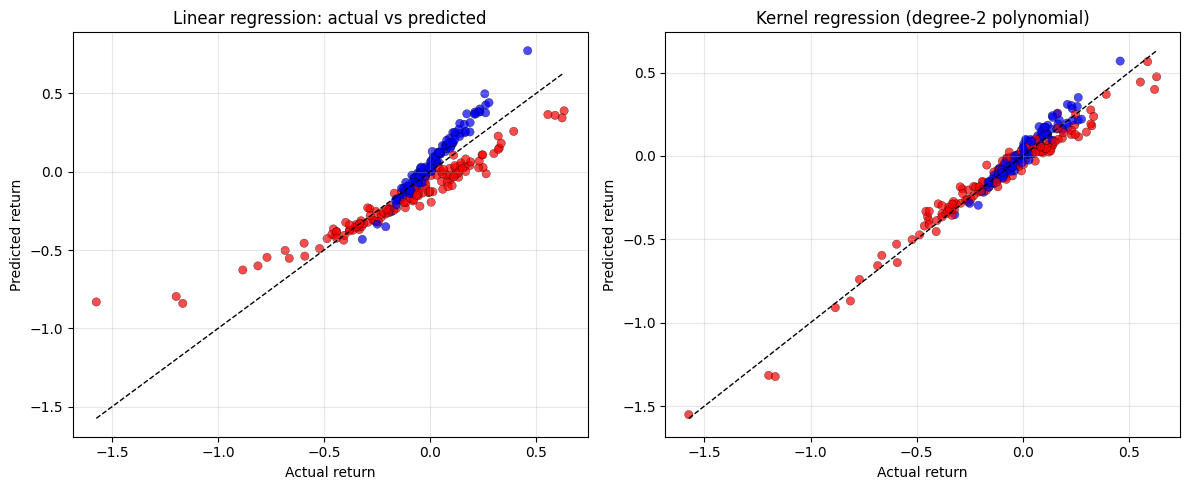

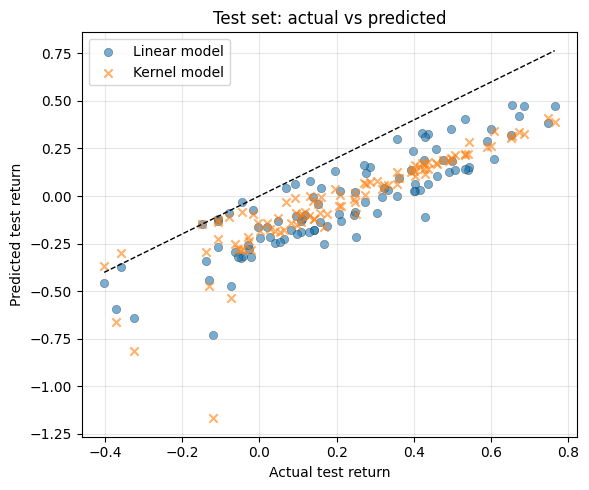

In [13]:
# Helper: Mean Squared Error
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# 1) Prediction errors (MSE) – train vs test, linear vs kernel
mse_linear_train = mse(y, y_pred_linear)
mse_kernel_train = mse(y, y_pred_kernel_train)

mse_linear_test  = mse(y_test, y_pred_linear_test)
mse_kernel_test  = mse(y_test, y_pred_kernel_test)

print("Prediction Error Comparison (MSE)")
print("=" * 60)
print(f"Training MSE  – Linear model : {mse_linear_train:.6f}")
print(f"Training MSE  – Kernel model : {mse_kernel_train:.6f}")
print("-" * 60)
print(f"Test MSE      – Linear model : {mse_linear_test:.6f}")
print(f"Test MSE      – Kernel model : {mse_kernel_test:.6f}")

# 2) Visualisation: TRAINING actual vs predicted
regimes = df_asset["Regime"].values
colors = np.where(regimes == "High Vol", "red", "blue")

plt.figure(figsize=(12, 5))

# Linear model
plt.subplot(1, 2, 1)
plt.scatter(y, y_pred_linear, c=colors, alpha=0.7,
            edgecolor="k", linewidth=0.3)
min_y, max_y = y.min(), y.max()
plt.plot([min_y, max_y], [min_y, max_y], "k--", lw=1)
plt.xlabel("Actual return")
plt.ylabel("Predicted return")
plt.title("Linear regression: actual vs predicted")
plt.grid(True, alpha=0.3)

# Kernel model
plt.subplot(1, 2, 2)
plt.scatter(y, y_pred_kernel_train, c=colors, alpha=0.7,
            edgecolor="k", linewidth=0.3)
plt.plot([min_y, max_y], [min_y, max_y], "k--", lw=1)
plt.xlabel("Actual return")
plt.ylabel("Predicted return")
plt.title("Kernel regression (degree-2 polynomial)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("train_actual_vs_pred_linear_vs_kernel.png",
            dpi=300, bbox_inches="tight")
plt.show()

# 3) Visualisation: TEST actual vs predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_linear_test,
            alpha=0.6, label="Linear model",
            edgecolor="k", linewidth=0.3)
plt.scatter(y_test, y_pred_kernel_test,
            alpha=0.6, label="Kernel model", marker="x")

min_y_test, max_y_test = y_test.min(), y_test.max()
plt.plot([min_y_test, max_y_test],
         [min_y_test, max_y_test], "k--", lw=1)

plt.xlabel("Actual test return")
plt.ylabel("Predicted test return")
plt.title("Test set: actual vs predicted")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("test_actual_vs_pred_linear_vs_kernel.png",
            dpi=300, bbox_inches="tight")
plt.show()
